In [1]:
"""
mo_plot_replicating_cres.ipynb

This script is used to plot properties of replicating and non-replicating CREs

authors: Roy Oelen

"""

'\nmo_plot_replicating_cres.ipynb\n\nThis script is used to plot properties of replicating and non-replicating CREs\n\nauthors: Roy Oelen\n\n'

In [2]:
#####################
# libraries we need #
#####################

# most files are zipped
import gzip
# pandas allows us to easily work with data
import pandas as pd
# for making the scatterplot
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
###############
# read inputs #
###############

# locations of the aggregated files
aggregated_betas_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/cre_eqtl/pseudobulk_replication/betas_ps/monocyte/betas.tsv.gz'
aggregated_ses_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/cre_eqtl/pseudobulk_replication/betas_ps/monocyte/ses.tsv.gz'
aggregated_ps_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/cre_eqtl/pseudobulk_replication/betas_ps/monocyte/ps.tsv.gz'
# location of the output file
meta_analysed_significance_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/cre_eqtl/pseudobulk_replication/betas_ps/monocyte/meta_analysis_results.txt.gz'
# location of significance in other tools
other_significance_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/cre_eqtl/pseudobulk_replication/betas_ps/monocyte/scenic_pseudobulk_cres.tsv.gz'

# read these files
aggregated_betas = pd.read_csv(aggregated_betas_loc, sep = '\t', header = 0, index_col = [0,1])
aggregated_ses = pd.read_csv(aggregated_ses_loc, sep = '\t', header = 0, index_col = [0,1])
aggregated_ps = pd.read_csv(aggregated_ps_loc, sep = '\t', header = 0, index_col = [0,1])
meta_analysed_significance = pd.read_csv(meta_analysed_significance_loc, sep = '\t', header = 0, index_col = 0)
other_significance = pd.read_csv(other_significance_loc, sep = '\t', header = 0, index_col = [0,1])

In [4]:
# make a third table with all the z scores
aggregated_zcores = aggregated_betas / aggregated_ses

In [5]:
# calculate the variation in the betas
betas_variation = aggregated_betas.var(axis=1)
# and the SD as well
betas_sd = aggregated_betas.std(axis=1)
# also for the z scores
zscores_variation = aggregated_zcores.var(axis = 1)
zscores_sd = aggregated_zcores.std(axis=1)
zscores_avg = aggregated_zcores.mean(axis=1)

In [6]:
# get indices as in the significance file
betas_variation.index = betas_variation.index.map(lambda x: '-'.join(x[::-1]))
betas_sd.index = betas_sd.index.map(lambda x: '-'.join(x[::-1]))
zscores_variation.index = zscores_variation.index.map(lambda x: '-'.join(x[::-1]))
zscores_sd.index = zscores_sd.index.map(lambda x: '-'.join(x[::-1]))
zscores_avg.index = zscores_avg.index.map(lambda x: '-'.join(x[::-1]))

In [7]:
# add this to the significance table
betas_variation_df = betas_variation.to_frame(name='beta_variation')
betas_sd_df = betas_sd.to_frame(name = 'beta_sd')
zscores_variation_df = zscores_variation.to_frame(name = 'zscore_variation')
zscores_sd_df = zscores_sd.to_frame(name = 'zscore_sd')
zscores_avg_df = zscores_avg.to_frame(name = 'zscore_avg')
meta_analysed_significance = meta_analysed_significance.merge(betas_variation_df, left_index = True, right_index = True)
meta_analysed_significance = meta_analysed_significance.merge(betas_sd_df, left_index = True, right_index = True)
meta_analysed_significance = meta_analysed_significance.merge(zscores_variation_df, left_index = True, right_index = True)
meta_analysed_significance = meta_analysed_significance.merge(zscores_sd_df, left_index = True, right_index = True)
meta_analysed_significance = meta_analysed_significance.merge(zscores_avg_df, left_index = True, right_index = True)

In [8]:
# add a column that deontes the sigificance
meta_analysed_significance['significance'] = meta_analysed_significance['meta_q_value'] < 0.05

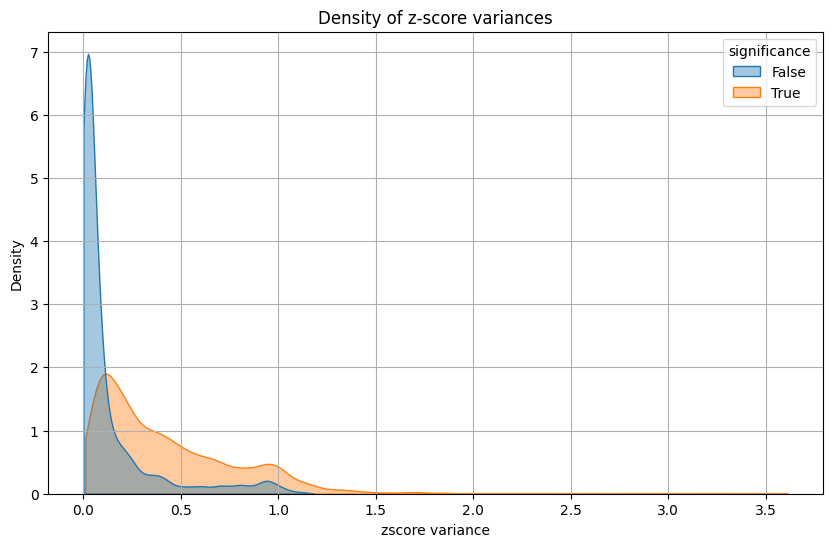

In [9]:
# plot variation in zscores of significant versus non-significant
plt.figure(figsize=(10, 6))
sns.kdeplot(data = meta_analysed_significance, x = "zscore_variation", hue = "significance", cut=0, fill=True, common_norm=False, alpha=0.4)
plt.title('Density of z-score variances')
plt.xlabel('zscore variance')
plt.ylabel('Density')
plt.grid(True)
plt.show()

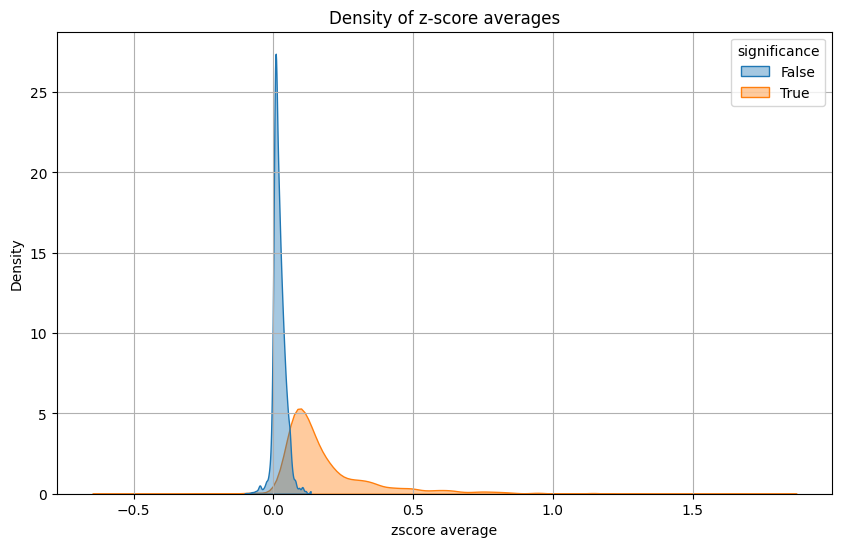

In [10]:
# plot average zscores of significant versus non-significant
plt.figure(figsize=(10, 6))
sns.kdeplot(data = meta_analysed_significance, x = "zscore_avg", hue = "significance", cut=0, fill=True, common_norm=False, alpha=0.4)
plt.title('Density of z-score averages')
plt.xlabel('zscore average')
plt.ylabel('Density')
plt.grid(True)
plt.show()

<Figure size 1000x600 with 0 Axes>

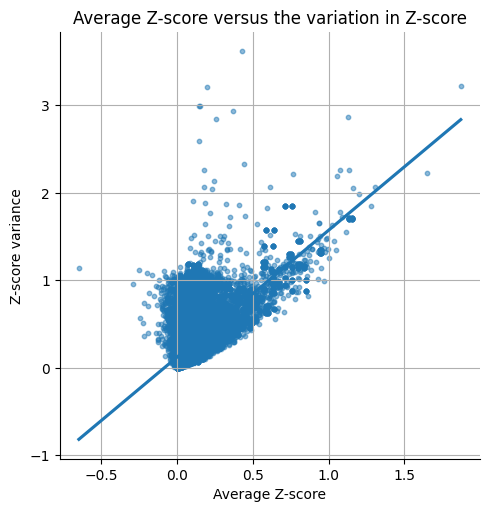

In [14]:
# plot the variation versus the average
plt.figure(figsize=(10, 6))
sns.lmplot(data=meta_analysed_significance, x='zscore_avg', y='zscore_variation', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Average Z-score versus the variation in Z-score')
plt.xlabel('Average Z-score')
plt.ylabel('Z-score variance')
plt.grid(True)
plt.show()

In [11]:
# take the other significance and join that onto it as well
other_significance_matchindex = other_significance.copy()
other_significance_matchindex.index = other_significance_matchindex.index.map(lambda x: '-'.join(x[::-1]))
meta_analysed_significance = meta_analysed_significance.merge(other_significance_matchindex, left_index = True, right_index = True)

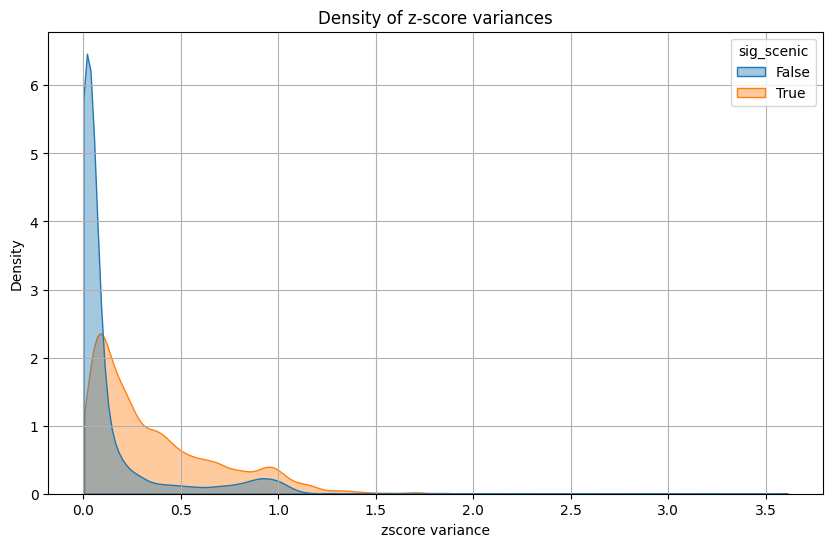

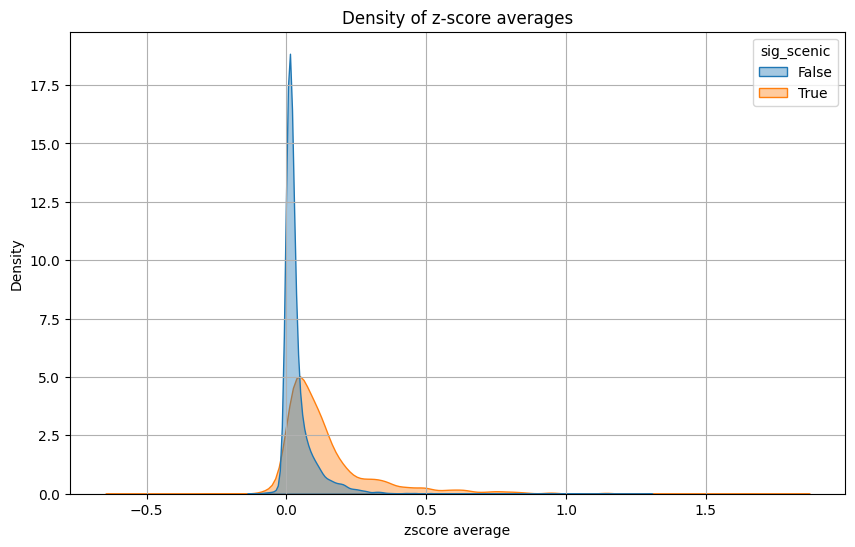

In [15]:
# variation again for SCENIC specifically
plt.figure(figsize=(10, 6))
sns.kdeplot(data = meta_analysed_significance, x = "zscore_variation", hue = "sig_scenic", cut=0, fill=True, common_norm=False, alpha=0.4)
plt.title('Density of z-score variances')
plt.xlabel('zscore variance')
plt.ylabel('Density')
plt.grid(True)
plt.show()
# plot average Z-score of significant versus non-significant
plt.figure(figsize=(10, 6))
sns.kdeplot(data = meta_analysed_significance, x = "zscore_avg", hue = "sig_scenic", cut=0, fill=True, common_norm=False, alpha=0.4)
plt.title('Density of z-score averages')
plt.xlabel('zscore average')
plt.ylabel('Density')
plt.grid(True)
plt.show()

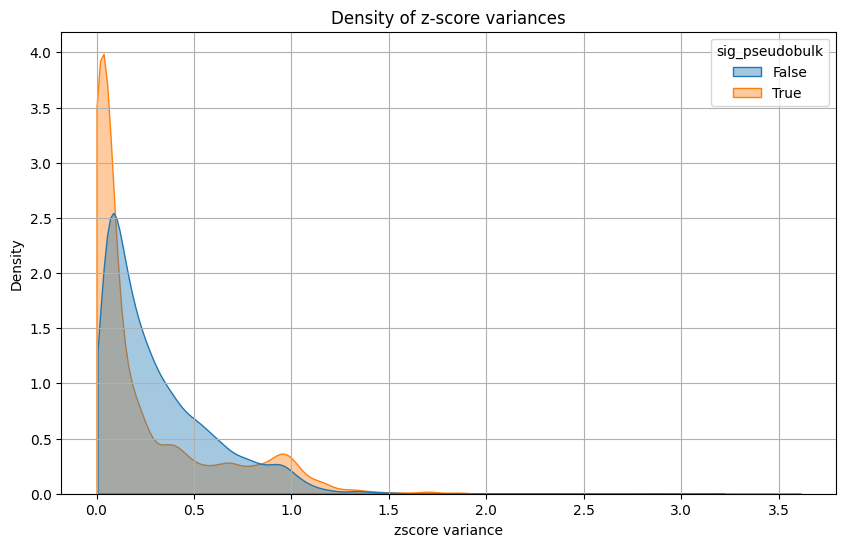

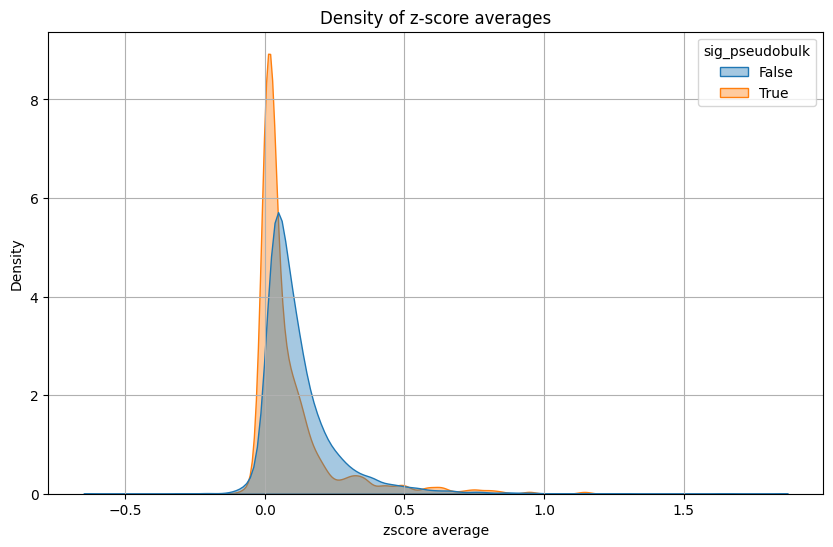

In [16]:
# variation again for SCENIC specifically
plt.figure(figsize=(10, 6))
sns.kdeplot(data = meta_analysed_significance, x = "zscore_variation", hue = "sig_pseudobulk", cut=0, fill=True, common_norm=False, alpha=0.4)
plt.title('Density of z-score variances')
plt.xlabel('zscore variance')
plt.ylabel('Density')
plt.grid(True)
plt.show()
# plot variation in betas of significant versus non-significant
plt.figure(figsize=(10, 6))
sns.kdeplot(data = meta_analysed_significance, x = "zscore_avg", hue = "sig_pseudobulk", cut=0, fill=True, common_norm=False, alpha=0.4)
plt.title('Density of z-score averages')
plt.xlabel('zscore average')
plt.ylabel('Density')
plt.grid(True)
plt.show()